# Import dan Load

In [38]:
# Library olah data default
import pandas as pd
import numpy as np

# Import dan Eksport .pkl
import joblib

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

# Analisis Panel
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score

In [39]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [3]:
df_property = pd.read_excel('https://drive.google.com/uc?id=1jk8SfEEmw80GQCA-2TekI8zmX0tjPK4J', sheet_name='HASIL PERHITUNGAN')

In [4]:
# Pastikan data diurutkan berdasarkan waktu
df_property = df_property.sort_values(by=['Emiten', 'Tahun'])
df_property.head(10)

,Emiten,Tahun,DER,TDR,ROE,TAN,LIQ,GRW,SIZ,TAX,AGE,NDTS
0,APLN,2020,1.676421,0.626367,0.015864,0.615793,1.895883,0.306884,31.045179,0.171031,2.302585,0.006210
1,APLN,2021,1.809463,0.644060,-0.046038,0.596135,1.634991,-0.141250,31.019171,0.330957,2.397895,0.009656
2,APLN,2022,1.295011,0.564272,0.181956,0.605022,1.958465,1.035556,30.985049,0.083012,2.484907,0.008786
3,APLN,2023,1.105918,0.525148,0.086572,0.607771,1.301291,-0.460209,30.974856,0.212327,2.564949,0.008564
4,APLN,2024,0.894971,0.472287,0.055901,0.584041,2.433227,0.192468,30.893710,0.144194,2.639057,0.007938
5,ASRI,2020,1.261504,0.557816,-0.110441,0.898430,0.674138,-0.593388,30.686286,0.656215,2.564949,0.004944
6,ASRI,2021,1.300101,0.565237,0.014988,0.861657,0.835173,1.014732,30.719058,0.078513,2.639057,0.002850
7,ASRI,2022,1.095247,0.522729,0.103204,0.836935,0.978071,0.578160,30.735560,0.057735,2.708050,0.002754
8,ASRI,2023,0.972839,0.493116,0.056573,0.869344,0.787737,-0.119620,30.732744,0.077696,2.772589,0.002225
9,ASRI,2024,0.942443,0.485184,0.005746,0.871374,0.764560,-0.132122,30.722928,0.084770,2.833213,0.002450


# Preprocessing

## Menggeser Data (Menambah Lag)

Untuk memprediksi data tahun depan dengan menambah kolom dari variabel Y (TDR) tahun depan

In [5]:
# 2. Buat Target Masa Depan (TDR Tahun Depan)
df_property['Target_TDR_Depan'] = df_property.groupby('Emiten')['TDR'].shift(-1)

# 3. Buat Variabel Masa Lalu (TDR Tahun Ini, untuk memprediksi tahun depan)
# Karena kita sudah menggeser target ke depan, kolom 'TDR' asli otomatis berfungsi sebagai Lag.
df_property.head()

,Emiten,Tahun,DER,TDR,ROE,TAN,LIQ,GRW,SIZ,TAX,AGE,NDTS,Target_TDR_Depan
0,APLN,2020,1.676421,0.626367,0.015864,0.615793,1.895883,0.306884,31.045179,0.171031,2.302585,0.006210,0.644060
1,APLN,2021,1.809463,0.644060,-0.046038,0.596135,1.634991,-0.141250,31.019171,0.330957,2.397895,0.009656,0.564272
2,APLN,2022,1.295011,0.564272,0.181956,0.605022,1.958465,1.035556,30.985049,0.083012,2.484907,0.008786,0.525148
3,APLN,2023,1.105918,0.525148,0.086572,0.607771,1.301291,-0.460209,30.974856,0.212327,2.564949,0.008564,0.472287
4,APLN,2024,0.894971,0.472287,0.055901,0.584041,2.433227,0.192468,30.893710,0.144194,2.639057,0.007938,NaN


In [6]:
# Buang baris yang tidak punya "Tahun Depan"
df_pred_tdr = df_property.dropna(subset=['Target_TDR_Depan'])

## Train-Test Split (Time-Based)

Tidak seperti train-test split biasa, untuk data waktu, harus ditentukan tahun pembatas untuk split. Jadi menggunakan data tahun historis untuk memprediksi masa depan. Ini untuk mencegah memprediksi data tahun lalu menggunakan informasi dari masa depan.

In [7]:
# ==========================================
# TIME-BASED SPLIT (Pemisahan Waktu)
# ==========================================
tahun_batas = 2023
train = df_pred_tdr[df_pred_tdr['Tahun'] < tahun_batas]
test = df_pred_tdr[df_pred_tdr['Tahun'] >= tahun_batas]

In [8]:
# Fitur yang digunakan: Rasio Keuangan + TDR saat ini (sebagai prediktor)
fitur = ['ROE', 'TAN', 'LIQ', 'GRW', 'SIZ', 'TAX', 'AGE', 'NDTS', 'TDR']

X_train = train[fitur]
y_train = train['Target_TDR_Depan']

X_test = test[fitur]
y_test = test['Target_TDR_Depan']

# Pembangunan Model Awal

In [9]:
# ==========================================
# TRAINING & EVALUASI
# ==========================================
rf_non_tune = RandomForestRegressor(n_estimators=100, random_state=42)
rf_non_tune.fit(X_train, y_train)

y_non_tune = rf_non_tune.predict(X_test)

print("=== AKURASI PREDIKSI MASA DEPAN (DER) ===")
print(f"R-Squared: {r2_score(y_test, y_non_tune):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_non_tune):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_non_tune)):.4f}")

=== AKURASI PREDIKSI MASA DEPAN (DER) ===
R-Squared: 0.8614
MAE: 0.0466
RMSE: 0.0737


In [10]:
# Lihat Feature Importance yang BARU!
importances_awal = pd.DataFrame({
    'Fitur': fitur,
    'Kekuatan': rf_non_tune.feature_importances_
}).sort_values(by='Kekuatan', ascending=False)

# print("\n=== FEATURE IMPORTANCE FORECASTING ===")
# importances_awal

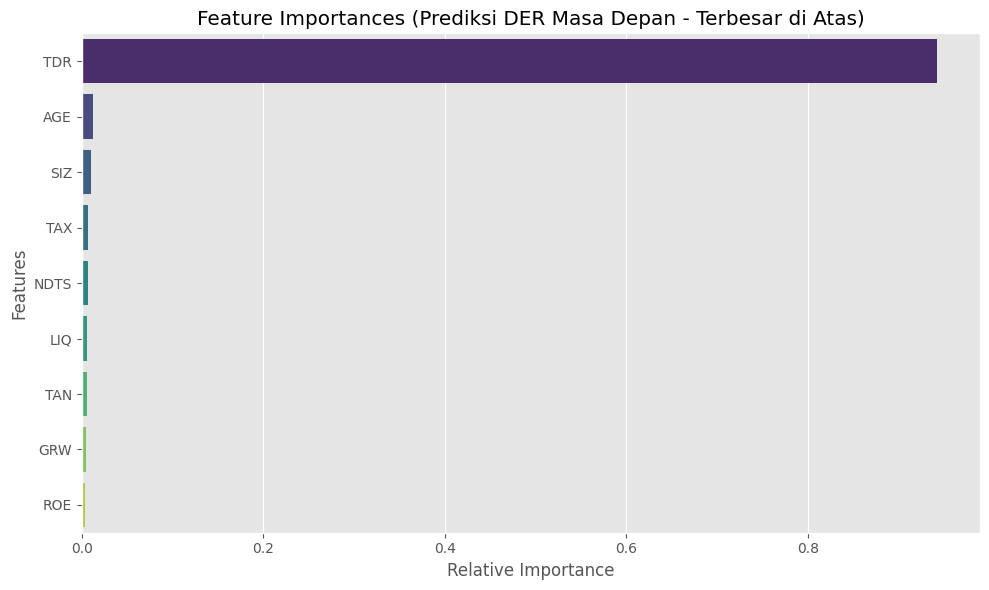

In [11]:
# Visualisasi menggunakan Seaborn (Inverted: Terbesar di atas)
plt.figure(figsize=(10, 6))
sns.barplot(data=importances_awal, x='Kekuatan', y='Fitur', hue='Fitur', palette='viridis', legend=False)
plt.title('Feature Importances (Prediksi DER Masa Depan - Terbesar di Atas)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [12]:
# 2. Setup TimeSeriesSplit
# Karena T kecil (4 tahun efektif), kita gunakan n_splits kecil, misal 3
tscv = TimeSeriesSplit(n_splits=3)

# 3. Inisialisasi Model & Hyperparameter Tuning
rf_tuning = RandomForestRegressor(random_state=42)

In [14]:
scores_cv = cross_val_score(rf_tuning, X_train, y_train, cv=tscv, scoring='r2')
print("R2 masing-masing = ", scores_cv)
print("Rata-rata = ", scores_cv.mean())
print("Simpangan baku = ", scores_cv.std())

R2 masing-masing =  [0.73354416 0.78477463 0.81761908]
Rata-rata =  0.7786459593713392
Simpangan baku =  0.03459594040318784


## Tanpa Parameter Default

Untuk mencegah overfitting

In [15]:
parameters_rf1 = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5],            # Dibatasi agar tidak overfit pada N=40
    'min_samples_leaf': [5, 10],       # Memastikan generalisasi
    'max_features': ['sqrt', None]     # 'None' berarti menggunakan semua fitur
}

Estimasi 40-an detik

In [16]:
# Grid Search dengan Cross Validation khusus waktu
search_rf1 = GridSearchCV(
    estimator=rf_tuning,
    param_grid=parameters_rf1,
    cv=tscv,
    scoring='r2',
    verbose=3,
    n_jobs=-1
)

search_rf1.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5], 'max_features': ['sqrt', None],
                         'min_samples_leaf': [5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='r2', verbose=3)

In [17]:
print("Best Parameters:", search_rf1.best_params_)
print("Best Score:", search_rf1.best_score_)

Best Parameters: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 500}
Best Score: 0.7926366410419964


In [18]:
rf1_tuned = search_rf1.best_estimator_

In [19]:
rf1_cv = cross_val_score(rf1_tuned, X_train, y_train, cv=tscv, scoring='r2')
print("R2 masing-masing = ", rf1_cv)
print("Rata-rata = ", rf1_cv.mean())
print("Simpangan baku = ", rf1_cv.std())

R2 masing-masing =  [0.69045634 0.86424782 0.82320576]
Rata-rata =  0.7926366410419964
Simpangan baku =  0.07416972892699247


## Pakai Parameter Default

In [20]:
parameters_rf2 = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 5, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', None, 1.0]
}

Estimasi 2 menit

In [21]:
# Grid Search dengan Cross Validation khusus waktu
search_rf2 = GridSearchCV(
    estimator=rf_tuning,
    param_grid=parameters_rf2,
    cv=tscv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

search_rf2.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, None],
                         'max_features': ['sqrt', None, 1.0],
                         'min_samples_leaf': [1, 5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='r2', verbose=1)

In [23]:
print("Best Parameters:", search_rf2.best_params_)
print("Best Score:", search_rf2.best_score_)

Best Parameters: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 500}
Best Score: 0.7964892557497266


In [24]:
rf2_tuned = search_rf2.best_estimator_

In [25]:
rf2_cv = cross_val_score(rf2_tuned, X_train, y_train, cv=tscv, scoring='r2')
print("R2 masing-masing = ", rf2_cv)
print("Rata-rata = ", rf2_cv.mean())
print("Simpangan baku = ", rf2_cv.std())

R2 masing-masing =  [0.74875978 0.8080892  0.83261879]
Rata-rata =  0.7964892557497266
Simpangan baku =  0.03520418640681029


## Visualisasi Sebelum dan Sesudah Tuning

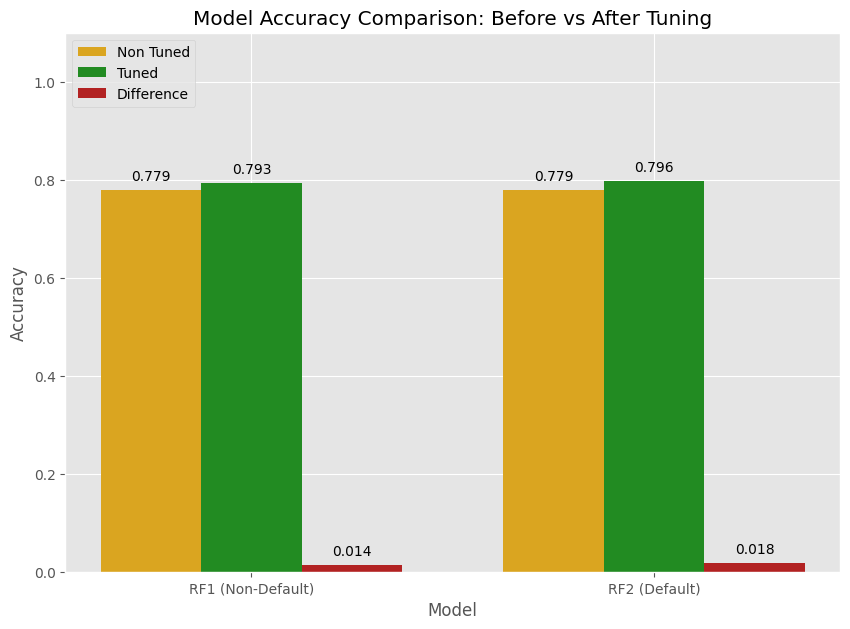

In [27]:
def addlabels(x,y,z):
    for i in range(len(x)):
      plt.text(i, x[i]+0.02, format(x[i], ".3f"), ha = 'center')
      plt.text(i+0.25, y[i]+0.02, format(y[i], ".3f"), ha = 'center')
      plt.text(i+0.5, z[i]+0.02, format(z[i], ".3f"), ha = 'center')

N = 2
ind = np.arange(N)
width = 0.25

plt.figure(figsize=(10,7))

non_tuning_acc = [scores_cv.mean(), scores_cv.mean()]
bar1 = plt.bar(ind, non_tuning_acc, width, color='goldenrod')

tuning_acc = [rf1_cv.mean(), rf2_cv.mean()]
bar2 = plt.bar(ind+width, tuning_acc, width, color='forestgreen')

selisih = []
for i in range(0, len(non_tuning_acc)):
  selisih.append(np.abs(non_tuning_acc[i]-tuning_acc[i]))

bar3 = plt.bar(ind+width*2, selisih, width, color = 'firebrick')

addlabels(non_tuning_acc, tuning_acc, selisih)
plt.xlabel("Model")
plt.ylabel('Accuracy')
plt.ylim([0, 1.1])

plt.xticks(ind+width,['RF1 (Non-Default)', 'RF2 (Default)'])
plt.legend( (bar1, bar2, bar3), ('Non Tuned', 'Tuned', 'Difference'), loc='upper left' )
plt.title("Model Accuracy Comparison: Before vs After Tuning")
plt.show()

# Evaluasi

## Data Train

In [28]:
y_val_non_tune = rf_non_tune.predict(X_train)

print("=== AKURASI PREDIKSI MASA DEPAN (DER) ===")
print(f"R-Squared: {r2_score(y_train, y_val_non_tune):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_val_non_tune):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_val_non_tune)):.4f}")

=== AKURASI PREDIKSI MASA DEPAN (DER) ===
R-Squared: 0.9872
MAE: 0.0145
RMSE: 0.0214


In [29]:
rf1_tuned.fit(X_train, y_train)

y_val_rf1 = rf1_tuned.predict(X_train)

print("=== R2 Pada Data Train ===")
print(f"R-Squared: {r2_score(y_train, y_val_rf1):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_val_rf1):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_val_rf1)):.4f}")

=== R2 Pada Data Train ===
R-Squared: 0.9427
MAE: 0.0312
RMSE: 0.0454


In [30]:
rf2_tuned.fit(X_train, y_train)

y_val_rf2 = rf2_tuned.predict(X_train)

print("=== R2 Pada Data Train ===")
print(f"R-Squared: {r2_score(y_train, y_val_rf2):.4f}")
print(f"MAE: {mean_absolute_error(y_train, y_val_rf2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_val_rf2)):.4f}")

=== R2 Pada Data Train ===
R-Squared: 0.9537
MAE: 0.0295
RMSE: 0.0408


## Data Test

In [31]:
y_pred_non_tune = rf_non_tune.predict(X_test)

print("=== AKURASI PREDIKSI MASA DEPAN (DER) ===")
print(f"R-Squared: {r2_score(y_test, y_pred_non_tune):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_non_tune):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_non_tune)):.4f}")

=== AKURASI PREDIKSI MASA DEPAN (DER) ===
R-Squared: 0.8614
MAE: 0.0466
RMSE: 0.0737


In [32]:
y_pred_rf1 = rf1_tuned.predict(X_test)

print("=== R2 Pada Data Test ===")
print(f"R-Squared: {r2_score(y_test, y_pred_rf1):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf1):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf1)):.4f}")

=== R2 Pada Data Test ===
R-Squared: 0.8617
MAE: 0.0499
RMSE: 0.0736


In [33]:
y_pred_rf2 = rf2_tuned.predict(X_test)

print("=== R2 Pada Data Test ===")
print(f"R-Squared: {r2_score(y_test, y_pred_rf2):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf2):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf2)):.4f}")

=== R2 Pada Data Test ===
R-Squared: 0.8530
MAE: 0.0517
RMSE: 0.0759


## Analisis Gap Train dan Test


In [34]:
# 1. Perbandingan R2 Train vs Test untuk deteksi Overfitting
summary_performa = pd.DataFrame({
    'Model': ['Non-Tuned', 'RF1 Tuned', 'RF2 Tuned'],
    'R2_Train': [
        r2_score(y_train, y_val_non_tune),
        r2_score(y_train, y_val_rf1),
        r2_score(y_train, y_val_rf2)
    ],
    'R2_Test': [
        r2_score(y_test, y_pred_non_tune),
        r2_score(y_test, y_pred_rf1),
        r2_score(y_test, y_pred_rf2)
    ]
})

summary_performa['Gap_Train_Test'] = summary_performa['R2_Train'] - summary_performa['R2_Test']
display(summary_performa)

,Model,R2_Train,R2_Test,Gap_Train_Test
0,Non-Tuned,0.987243,0.861433,0.125810
1,RF1 Tuned,0.942687,0.861654,0.081033
2,RF2 Tuned,0.953687,0.853036,0.100652


Model RF1 Tuned menang jauh di sini karena punya nilai R2 Test terbaik dan juga memiliki Gap Train Test terendah

In [35]:
# 2. Cek apakah Feature Importance bergeser secara signifikan
importances_tuned = pd.DataFrame({
    'Fitur': fitur,
    'Kekuatan_Awal': rf_non_tune.feature_importances_,
    'Kekuatan_Tuned_RF1': rf1_tuned.feature_importances_,
    'Kekuatan_Tuned_RF2': rf2_tuned.feature_importances_
}).sort_values(by='Kekuatan_Awal', ascending=False)

importances_tuned

,Fitur,Kekuatan_Awal,Kekuatan_Tuned_RF1,Kekuatan_Tuned_RF2
8,TDR,0.942419,0.988046,0.975810
6,AGE,0.012588,0.000474,0.009644
4,SIZ,0.010017,0.004886,0.004678
5,TAX,0.007346,0.002042,0.004396
7,NDTS,0.006950,0.001050,0.002270
2,LIQ,0.006405,0.001764,0.001944
1,TAN,0.006319,0.000530,0.000491
3,GRW,0.004818,0.000659,0.000489
0,ROE,0.003138,0.000550,0.000279


## Visualisasi Prediksi dan Aktual

In [36]:
actual_vs_prediction = pd.DataFrame({
    'Actual_DER_Next_Year': y_test,
    'RF_Non_Tune': y_pred_non_tune,
    'RF1': y_pred_rf1,
    'RF2': y_pred_rf2
})

# Reset index for a cleaner look
actual_vs_prediction = actual_vs_prediction.reset_index(drop=True)

actual_vs_prediction.sample(5)

,Actual_DER_Next_Year,RF_Non_Tune,RF1,RF2
30,0.111056,0.115427,0.098807,0.103633
25,0.179738,0.210311,0.195977,0.197251
21,0.462170,0.460340,0.453937,0.454936
17,0.357932,0.450979,0.435730,0.439847
8,0.377568,0.323334,0.324272,0.317578


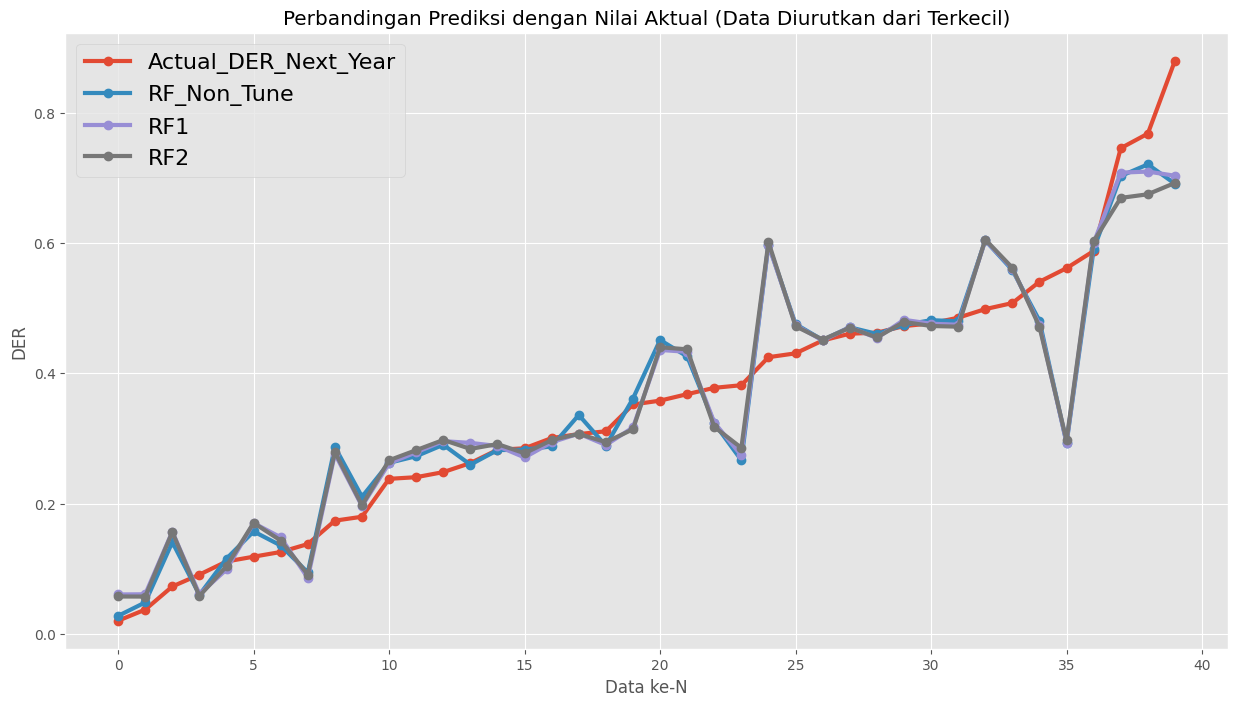

In [37]:
plt.plot(actual_vs_prediction.sort_values(by ='Actual_DER_Next_Year').reset_index(drop = True),
         linewidth = 3,
         marker = 'o'
         )
plt.title('Perbandingan Prediksi dengan Nilai Aktual (Data Diurutkan dari Terkecil)')
plt.xlabel('Data ke-N')
plt.ylabel('DER')
plt.legend(actual_vs_prediction.columns, fontsize=16)
plt.show()

# Export dan Kesimpulan

Kesimpulan yang didapatkan:

* Pada Data Train, performa RF1 diukur dari ketiga metrik R2, MAE, dan RMSE memang yang terburuk dibandingkan model lainnya. Namun hal ini memang sengaja untuk menghindari **overfitting**.
* Pada Data Test, RF1 adalah model terbaik berdasarkan parameter metrik R2 dan RMSE. Selain itu juga diperkuat dengan Gap R2 antara Train dan Test yang paling kecil. Ini membuat model RF1 jauh lebih unggul dan untuk itu akan di-export untuk digunakan.

In [40]:
# Ekspor Model Sederhana
# Karena preprocessing dilakukan manual pada dataframe, kita cukup menyimpan model yang sudah di-fit
joblib.dump(rf1_tuned, '03_model_rf_tdr.pkl')

print("Model Random Forest (RF1 Tuned) berhasil diekspor ke: 03_model_rf_tdr.pkl")

Model Random Forest (RF1 Tuned) berhasil diekspor ke: 03_model_rf_tdr.pkl
